In [16]:
import numpy as np   
import pandas as pd
import scanpy as sc
import seaborn as sb
from scipy import sparse
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
sc.settings.verbosity = 3         

sc.logging.print_header()            
sc.settings.set_figure_params(dpi=80,   
 dpi_save=300,fontsize=14,format='pdf',
 facecolor='none') 
plt.rcParams['pdf.fonttype'] = 42  
plt.rcParams['font.family'] = 'sans-serif'  
plt.rcParams['font.sans-serif'] = ['Arial']


scanpy==1.9.8 anndata==0.9.2 umap==0.5.6 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 igraph==0.11.6 louvain==0.8.2 pynndescent==0.5.13


In [17]:
adata=sc.read_h5ad("GSE124880_PCA_harmony.h5ad")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:15)


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


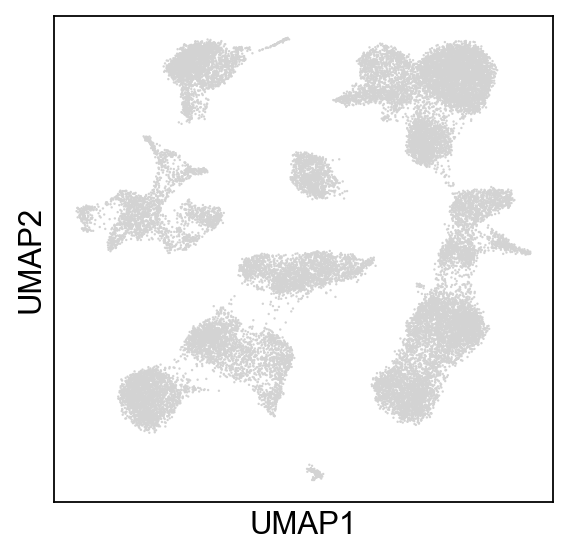

In [18]:
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_neighbors=15, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata)

running Leiden clustering
    finished: found 39 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:04)


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


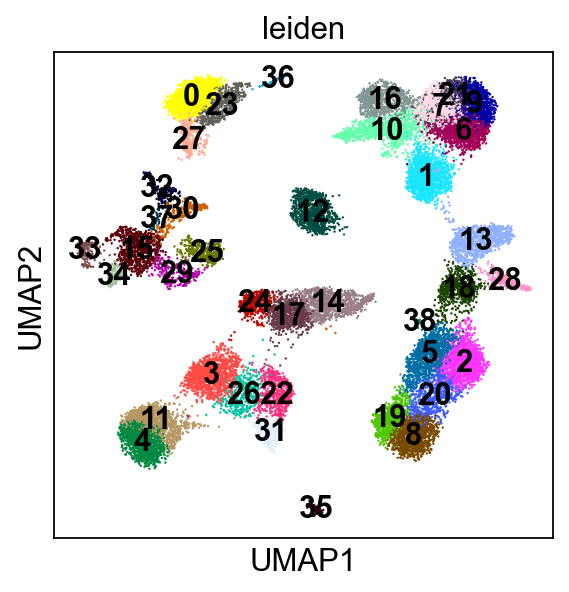

In [19]:
sc.tl.leiden(adata,resolution=3.5) 
sc.pl.umap(adata, color=['leiden'],legend_loc='on data')#

In [20]:
import scanpy as sc
import pandas as pd

groupby_key = "leiden"
reference = "rest"
method = "wilcoxon"
output_file = "DEG_leiden_result.xlsx"
sort_by = "logfoldchanges"
top_n = None

sc.tl.rank_genes_groups(
    adata,
    groupby=groupby_key,
    reference=reference,
    method=method
)

groups = adata.obs[groupby_key].astype(str).unique()

with pd.ExcelWriter(output_file) as writer:

    for g in groups:

        df = sc.get.rank_genes_groups_df(
            adata,
            group=g
        )

        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=False)

        if top_n is not None:
            df = df.head(top_n)

        sheet_name = f"{groupby_key}_{g}"[:31]

        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Saved DEG results to: {output_file}")

ranking genes


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\tools\_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\tools\_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\tools\_rank_genes_groups.py:401: PerformanceWarning: Da

    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:40)
Saved DEG results to: DEG_leiden_result.xlsx


In [21]:
cluster2annotation = {
    '0': 'pDCs',
    '1': 'CD8+ T',
    '2': 'NKp46+ ILC3s',
    '3': 'GC B',
    '4': 'Resting B',
    '5': 'NKp46+ ILC3s',
    '6': 'CD4+ T',
    '7': 'CD4+ T',
    '8': 'Ccr6+ ILC3s',
    '9': 'CD4+ T',
    '10': 'CD4+ T',
    '11': 'Resting B',
    '12': 'ILC2s',
    '13': 'NK',
    '14': 'Plasma Cells',
    '15': 'cDCs',
    '16': 'CD4+ T',
    '17': 'Plasma Cells',
    '18': 'ILC1s',
    '19': 'Ccr6+ ILC3s',
    '20': 'DN ILC3s',
    '21': 'CD4+ T',
    '22': 'GC B',
    '23': 'pDCs',
    '24': 'Plasma Cells',
    '25': 'cDCs',
    '26': 'GC B',
    '27': 'pDCs',
    '28': 'gdT',
    '29': 'cDCs',
    '30': 'Macrophages',
    '31': 'GC B',
    '32': 'Macrophages',
    '33': 'cDCs',
    '34': 'cDCs',
    '35': 'Mast cells',
    '36': 'Neutrophils',
    '37': 'Macrophages',
    '38': 'NKp46+ ILC3s'
}
adata.obs['cell type'] = adata.obs['leiden'].map(cluster2annotation).astype('category')

In [22]:
marker_genes = [
    'Cd3d', 'Cd3e', 'Trac', 'Cd4', 'Lef1',     
    'Cd8a',                                     
    'Tcrg-C4', 'Trdc', 'Cd7', 'Nkg7',           
    'Gzma', 'Eomes', 'Gzma', 'Prf1',            
    'Xcl1', 'Ccl5', 'Ifngr1', 'Ncr1',           
    'Klrg1', 'Calca',                          
    'Il7r', 'Rorc',                    
    'Ccr6', 'Il22',                            
    'Cd79a', 'Cd79b', 'Cd19', 'Ighd', 'Ighm',  
    'Hmgb2', 'Bcl6',                            
    'Sdc1', 'Igha', 'Xbp1', 'Igha',             
    'H2-Ab1', 'Cst3', 'Mdh2',                  
    'Siglech', 'Bst2',                      
    'Fcer1g', 'Csf1r', 'Lyz2',                 
    'Fcer1a', 'Mcpt1', 'Kit',                 
    'S100a8', 'S100a9'                         
]

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


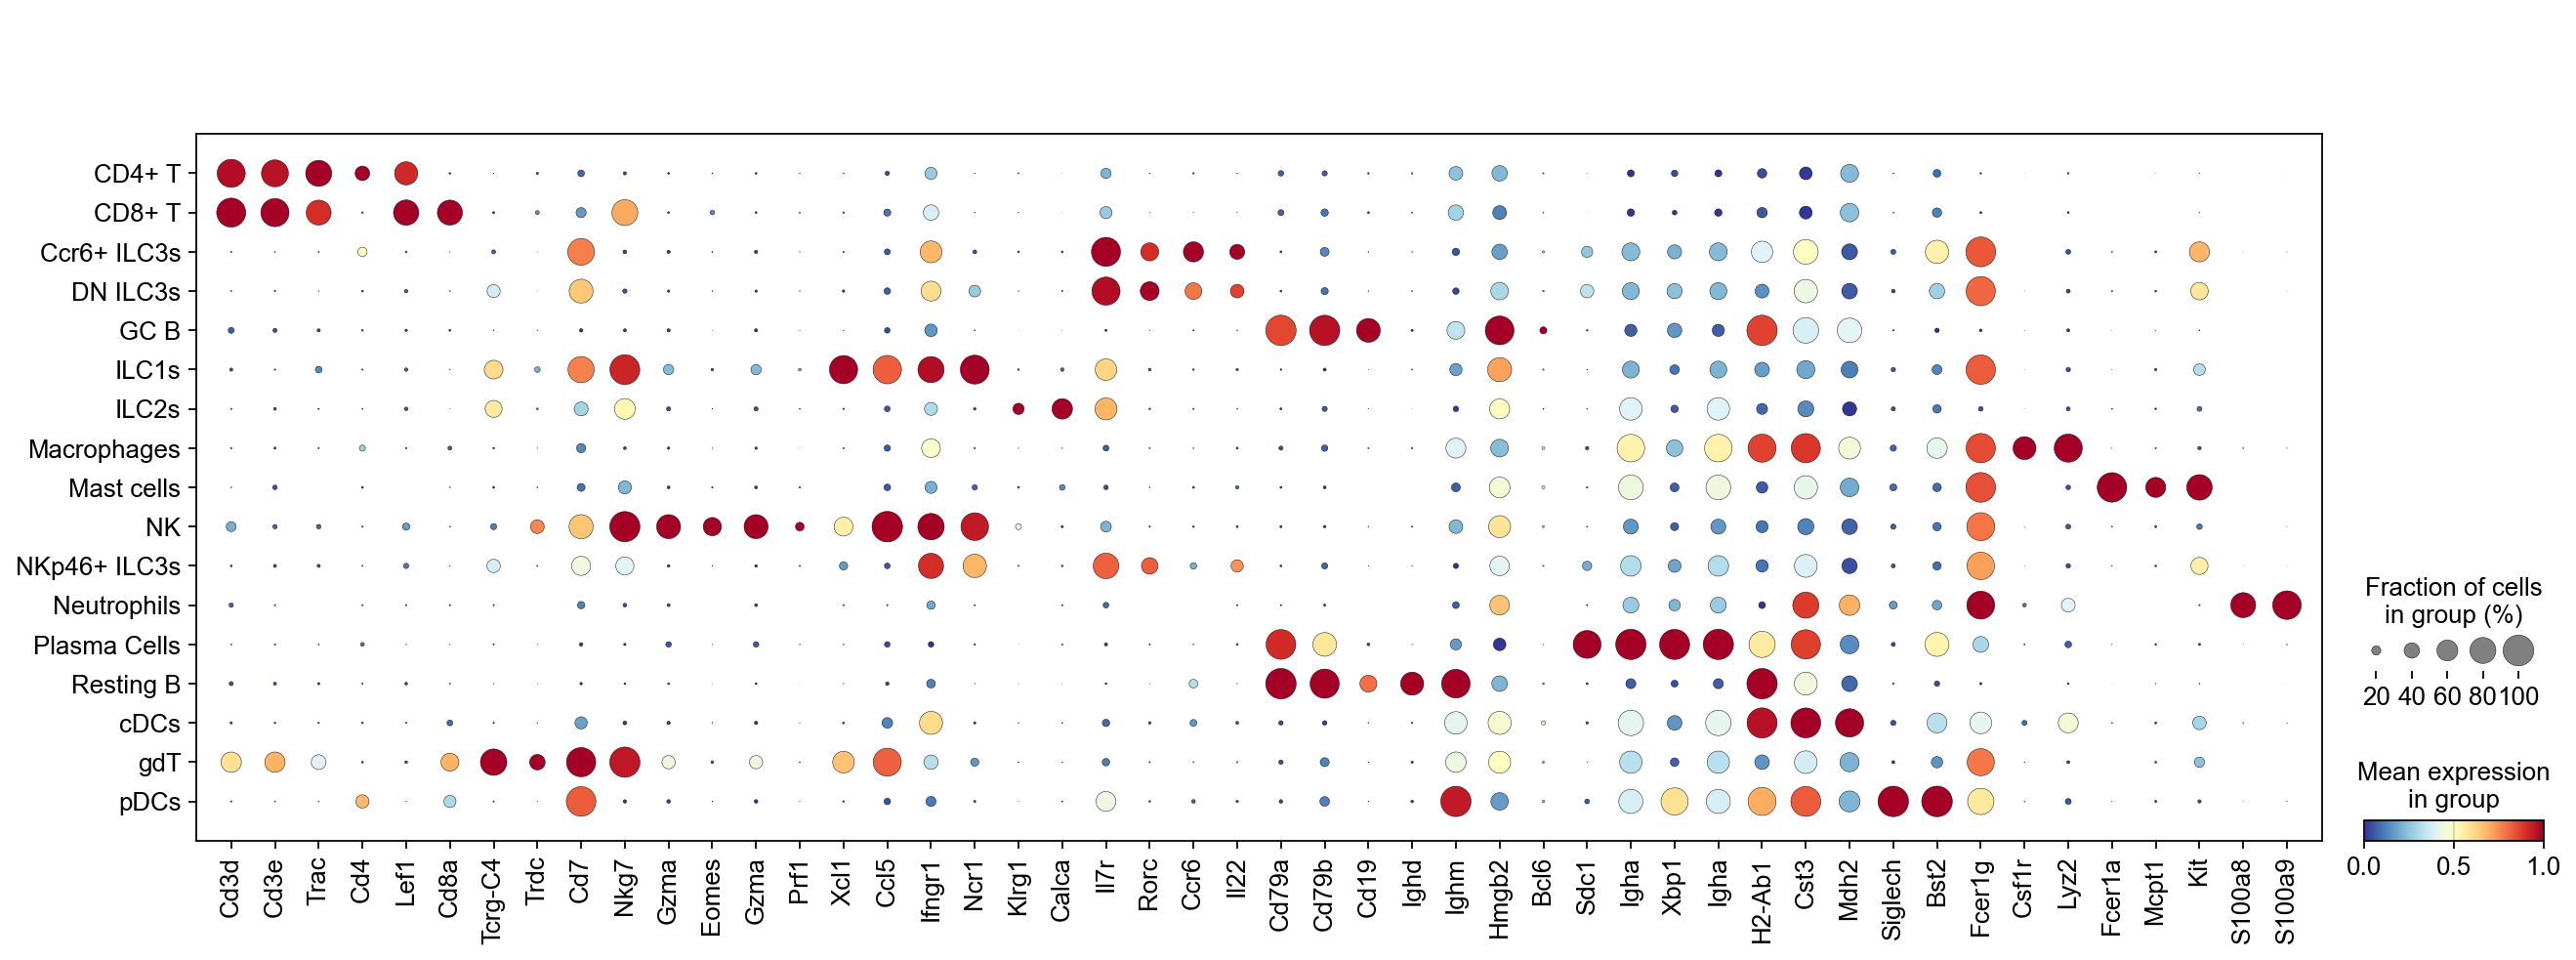

In [23]:
ax = sc.pl.dotplot(adata, marker_genes, groupby='cell type',dendrogram=False, swap_axes=False, 
                   standard_scale="var",cmap='RdYlBu_r', 
                      dot_min=0,  
                     dot_max=1,   
                     vmin=0,  
                      vmax=1,save='cell_type_dopplot.pdf' )  

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


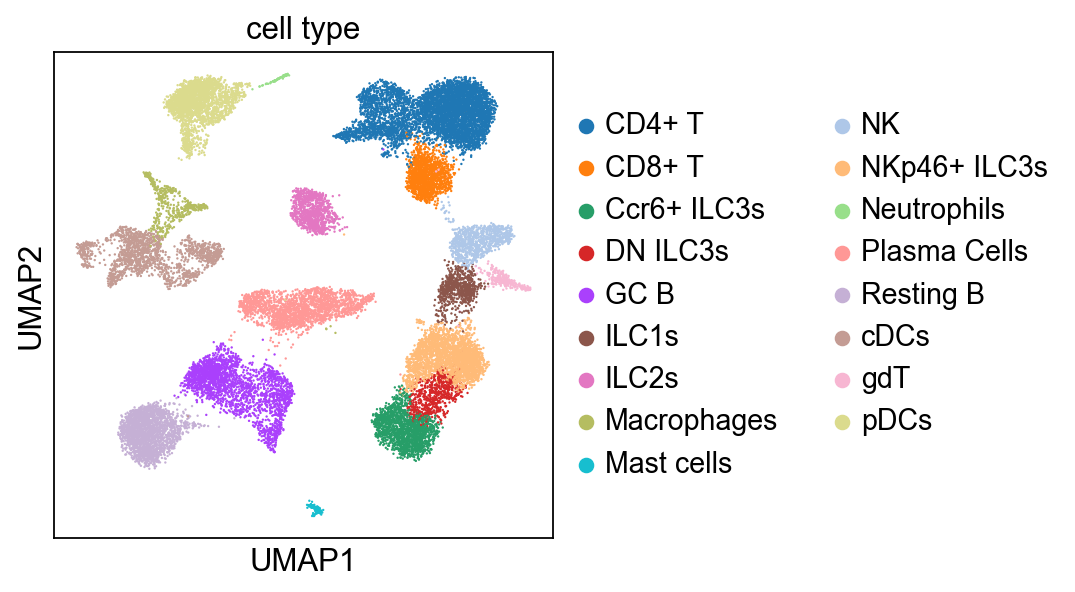

In [24]:
sc.pl.umap(adata, color=['cell type'])

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


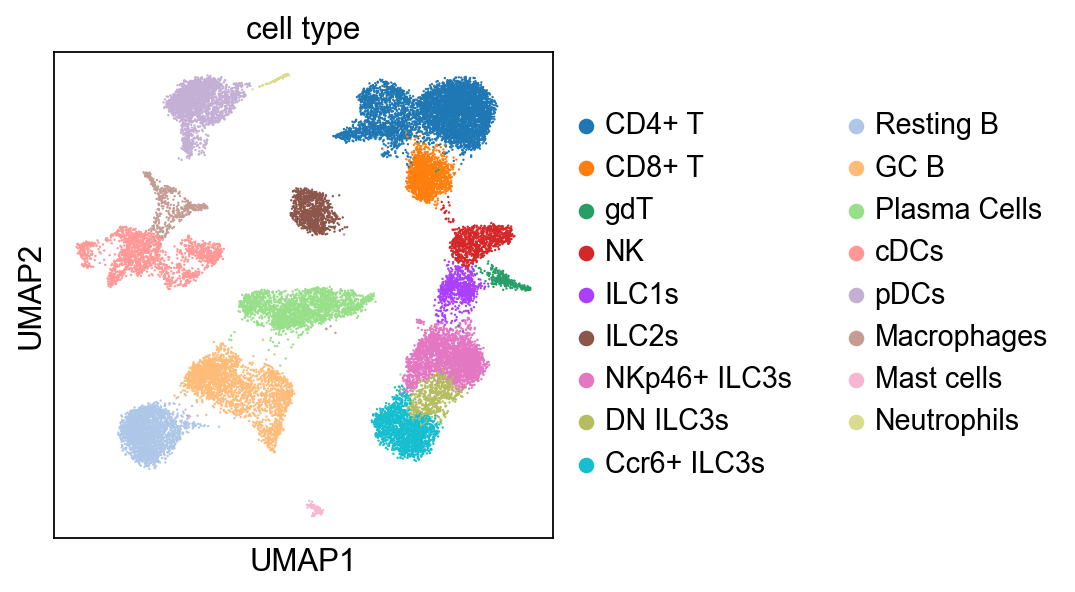

In [25]:
cell_order = [
    'CD4+ T',
    'CD8+ T',
    'gdT',
    'NK',
    'ILC1s',
    'ILC2s',
    'NKp46+ ILC3s',
    'DN ILC3s',
    'Ccr6+ ILC3s',
    'Resting B',
    'GC B',
    'Plasma Cells',
    'cDCs',
    'pDCs',
    'Macrophages',
    'Mast cells',
    'Neutrophils'
]

cell_colors = [
    '#1f77b4',
    '#ff7f0e',
    '#279e68',
    '#d62728',
    '#aa40fc',
    '#8c564b',
    '#e377c2',
    '#b5bd61',
    '#17becf',
    '#aec7e8',
    '#ffbb78',
    '#98df8a',
    '#ff9896',
    '#c5b0d5',
    '#c49c94',
    '#f7b6d2',
    '#dbdb8d'
]


adata.obs['cell type'] = adata.obs['cell type'].astype('category')

adata.obs['cell type'] = adata.obs['cell type'].cat.reorder_categories(
    cell_order,
    ordered=True
)


adata.uns['cell type_colors'] = cell_colors

sc.pl.umap(
    adata,
    color='cell type',
    legend_loc='right margin',save='cell_type.pdf'
)

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


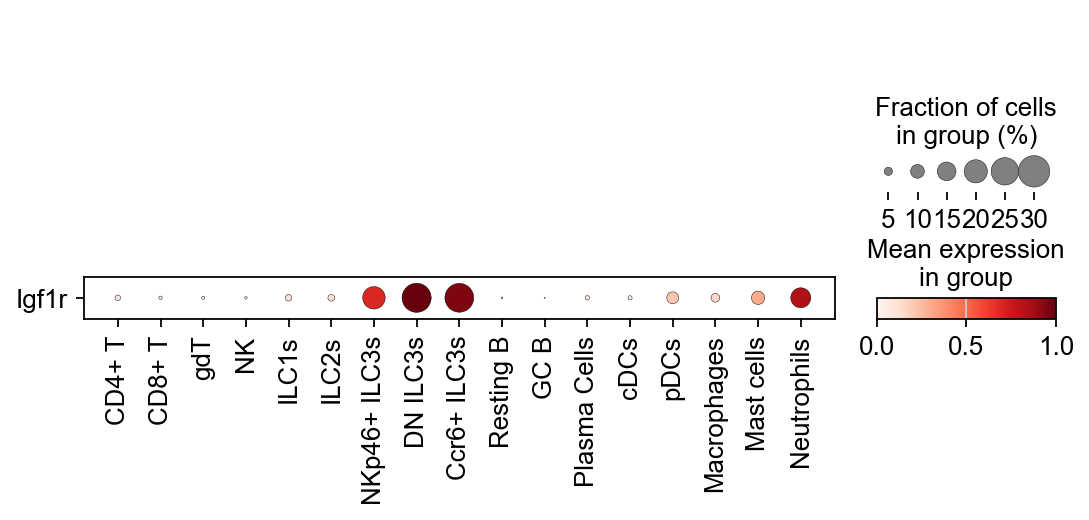

In [26]:
with rc_context({"figure.figsize": (8, 3)}):
    sc.pl.dotplot(adata, ["Igf1r"], groupby="cell type",
                   swap_axes=True,standard_scale="var",                                    
                     vmin=0,  
                      vmax=1,
                      save='Igf1r.pdf' )   # 最大颜色值

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


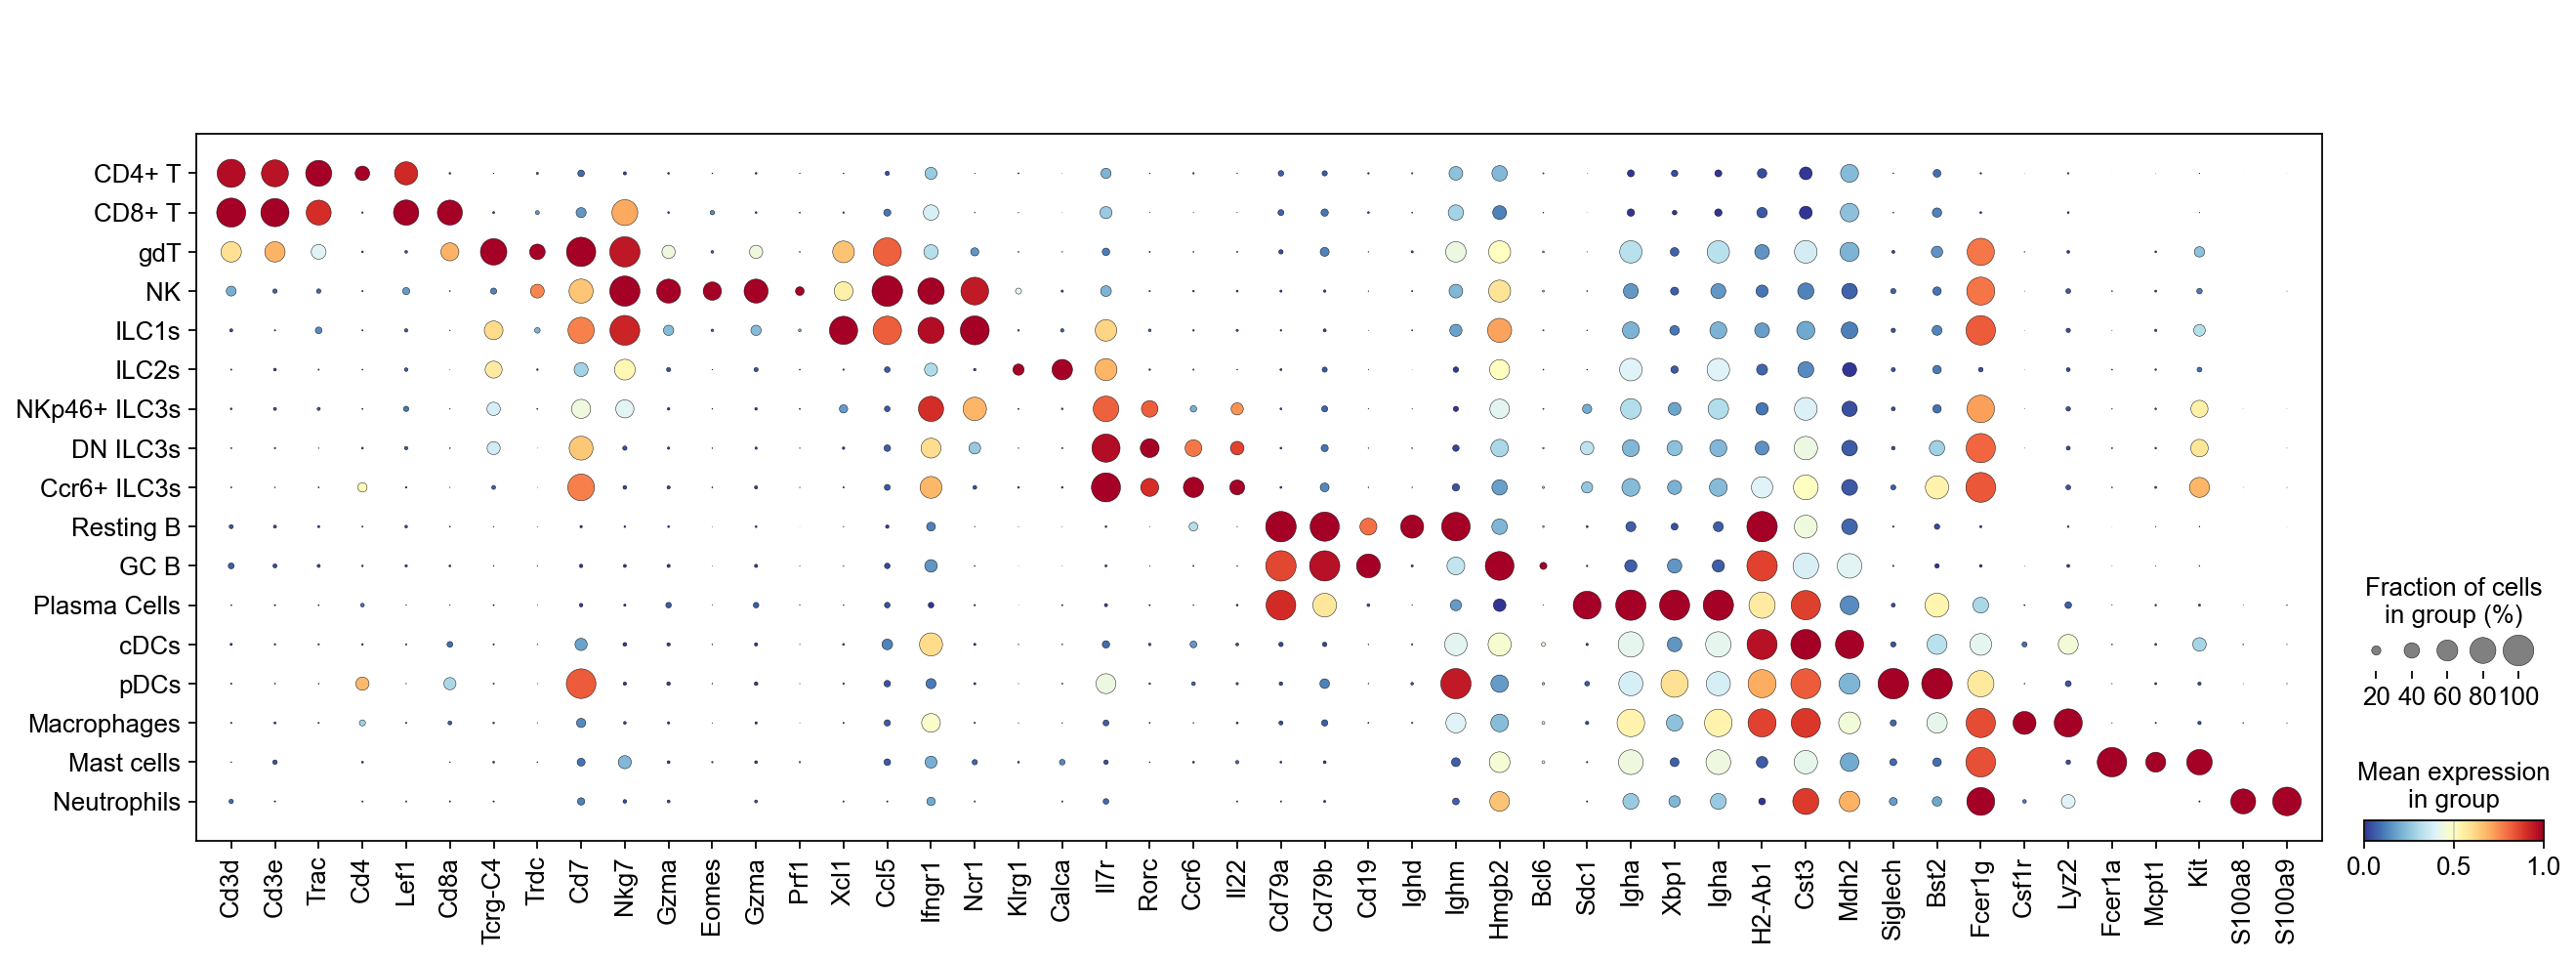

In [27]:
ax = sc.pl.dotplot(adata, marker_genes, groupby='cell type',dendrogram=False, swap_axes=False, 
                   standard_scale="var",cmap='RdYlBu_r', 
                      dot_min=0,  
                     dot_max=1,   
                     vmin=0,  
                      vmax=1,save='cell_type_dopplot.pdf' )  

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


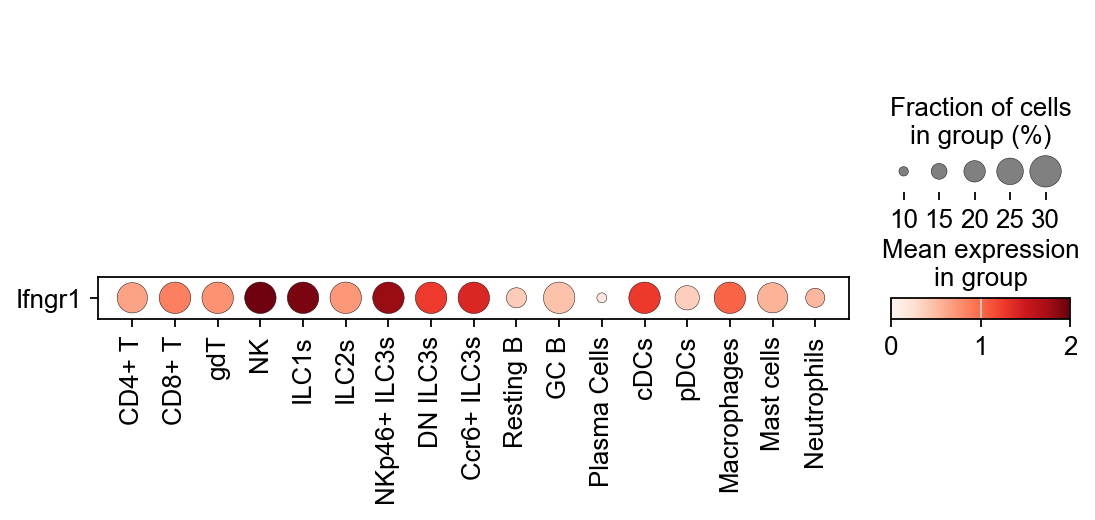

In [28]:
with rc_context({"figure.figsize": (8, 3)}):
    sc.pl.dotplot(adata, ["Ifngr1"], groupby="cell type",
                   swap_axes=True,
                      dot_min=0.05,  # 最小点大小
                     dot_max=0.3,  # 最大点大小  
                     vmin=0,  # 最小颜色值
                      vmax=2,save='Ifngr1.pdf' )   # 最大颜色值

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


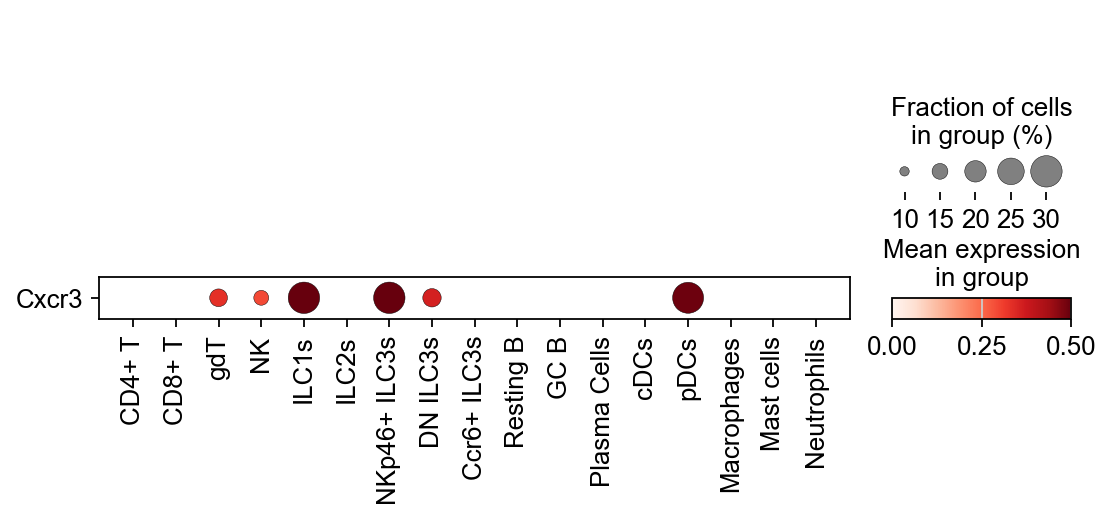

In [29]:
with rc_context({"figure.figsize": (8, 3)}):
    sc.pl.dotplot(adata, ["Cxcr3"], groupby="cell type",
                   swap_axes=True,
                      dot_min=0.05, 
                      dot_max=0.3,                    
                     vmin=0,  
                      vmax=0.5,
                      save='cxcr3.pdf' )   # 最大颜色值